In [2]:
import zipfile
import pandas as pd
with zipfile.ZipFile('/content/archive (4) (1).zip', 'r') as zip_ref:
    zip_ref.extractall()
df = pd.read_csv("train.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [4]:
# Fill missing values
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)

# Check again
df.isnull().sum()

/tmp/ipykernel_25743/2945804166.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
/tmp/ipykernel_25743/2945804166.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


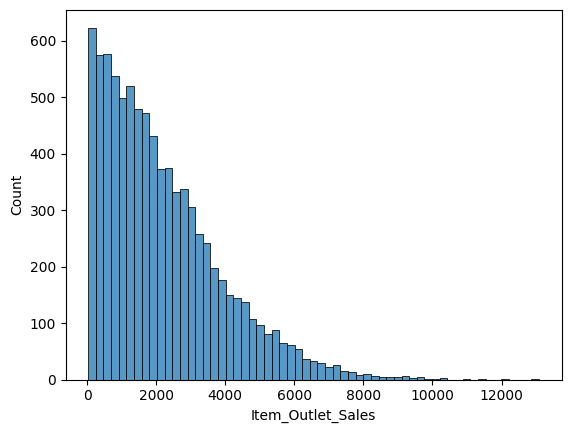

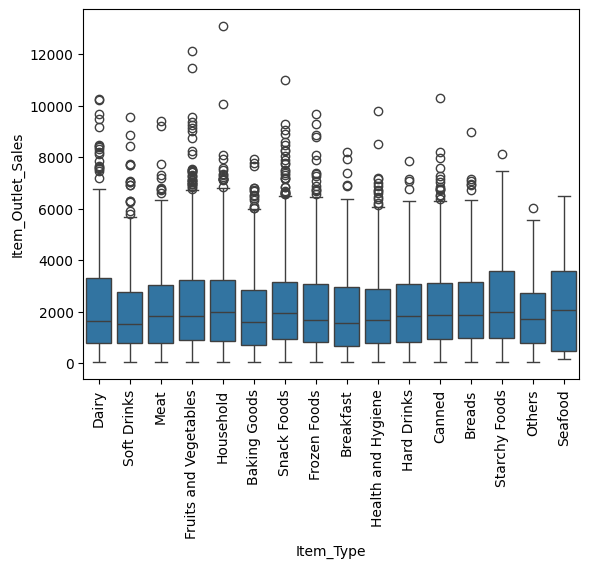

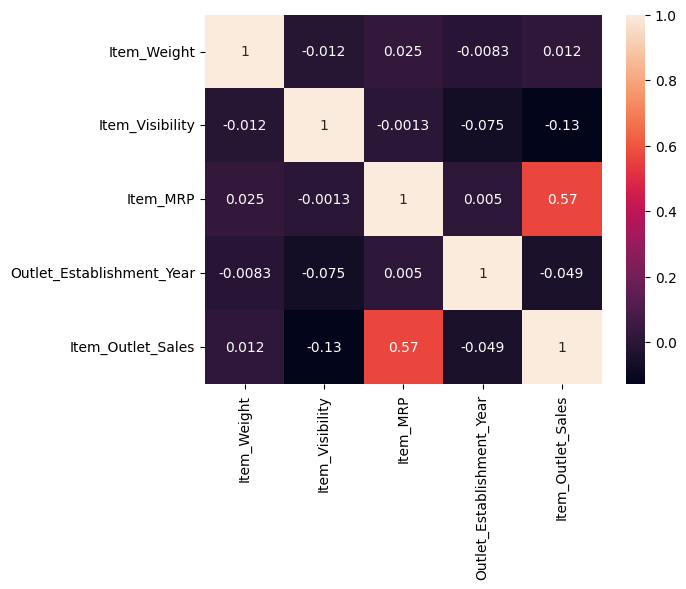

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sales distribution
sns.histplot(df['Item_Outlet_Sales'])
plt.show()

# Sales vs Item Type
sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=df)
plt.xticks(rotation=90)
plt.show()

# Correlation
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [6]:
df['Item_Age'] = 2026 - df['Outlet_Establishment_Year']
df.drop(['Outlet_Establishment_Year'], axis=1, inplace=True)

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = model.predict(X_test)

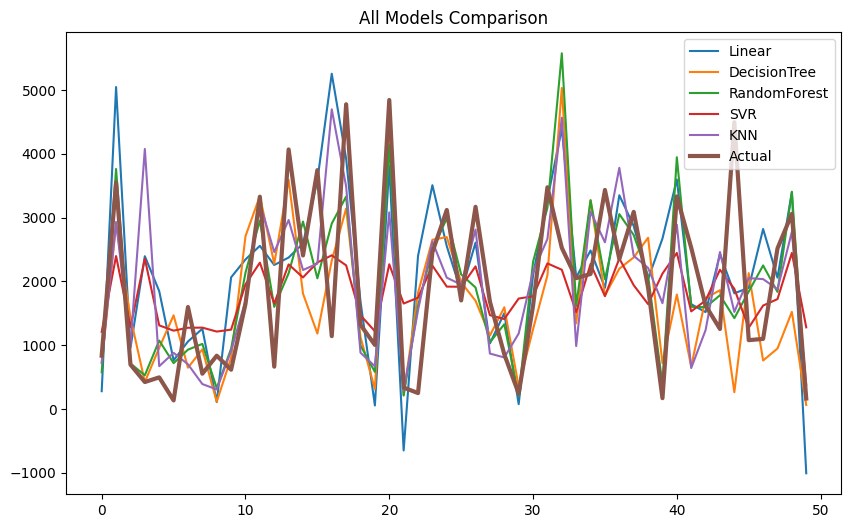

In [12]:
plt.figure(figsize=(10,6))

for name, pred in results.items():
    plt.plot(pred[:50], label=name)

plt.plot(y_test.values[:50], label="Actual", linewidth=3)

plt.title("All Models Comparison")
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics = []

for name, pred in results.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape_val = mape(y_test, pred)

    metrics.append([name, mae, rmse, r2, mape_val])

import pandas as pd
metrics_df = pd.DataFrame(metrics, columns=["Model","MAE","RMSE","R2","MAPE"])
print(metrics_df)

          Model          MAE         RMSE        R2        MAPE
0        Linear   943.271411  1240.681137  0.460275  116.305725
1  DecisionTree  1035.804390  1479.043942  0.232966   67.206774
2  RandomForest   779.572279  1099.213572  0.576341   53.135074
3           SVR  1132.480583  1519.376775  0.190562  152.823416
4           KNN   890.294561  1228.205293  0.471075   80.179802


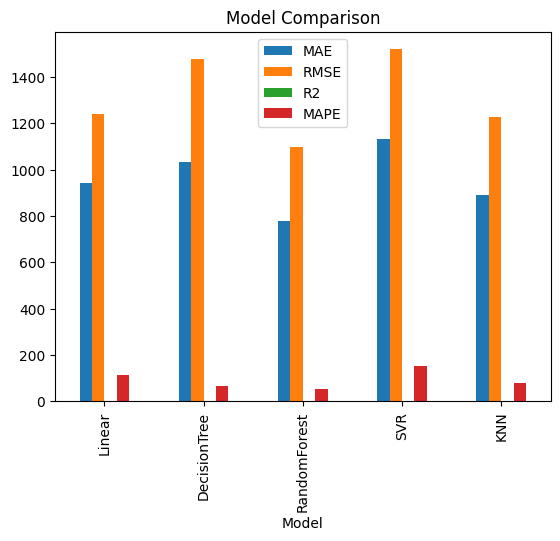

In [14]:
import matplotlib.pyplot as plt

metrics_df.set_index("Model").plot(kind='bar')
plt.title("Model Comparison")
plt.show()

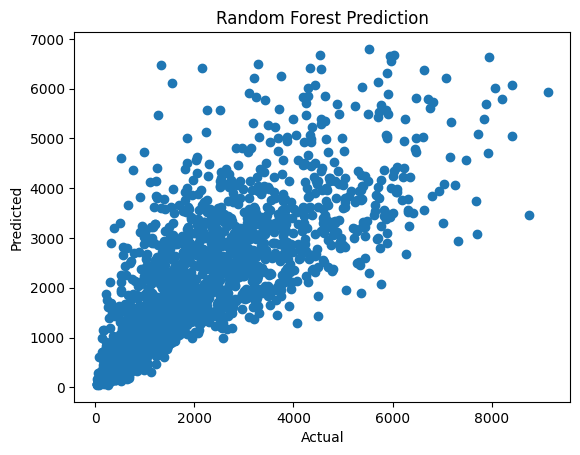

In [15]:
best_pred = results["RandomForest"]

plt.scatter(y_test, best_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Prediction")
plt.show()

In [16]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [17]:
base_models = [
    ('lr', LinearRegression()),
    ('dt', DecisionTreeRegressor()),
    ('rf', RandomForestRegressor()),
    ('svr', SVR()),
    ('knn', KNeighborsRegressor())
]

In [18]:
meta_model = LinearRegression()

In [19]:
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model
)

In [20]:
stack_model.fit(X_train, y_train)

StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('dt', DecisionTreeRegressor()),
                              ('rf', RandomForestRegressor()), ('svr', SVR()),
                              ('knn', KNeighborsRegressor())],
                  final_estimator=LinearRegression())

In [21]:
stack_pred = stack_model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAPE function
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mae = mean_absolute_error(y_test, stack_pred)
rmse = np.sqrt(mean_squared_error(y_test, stack_pred))
r2 = r2_score(y_test, stack_pred)
mape_val = mape(y_test, stack_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("MAPE:", mape_val)

MAE: 783.2566748436673
RMSE: 1080.3250997504247
R2: 0.590775800243059
MAPE: 63.60988077859149


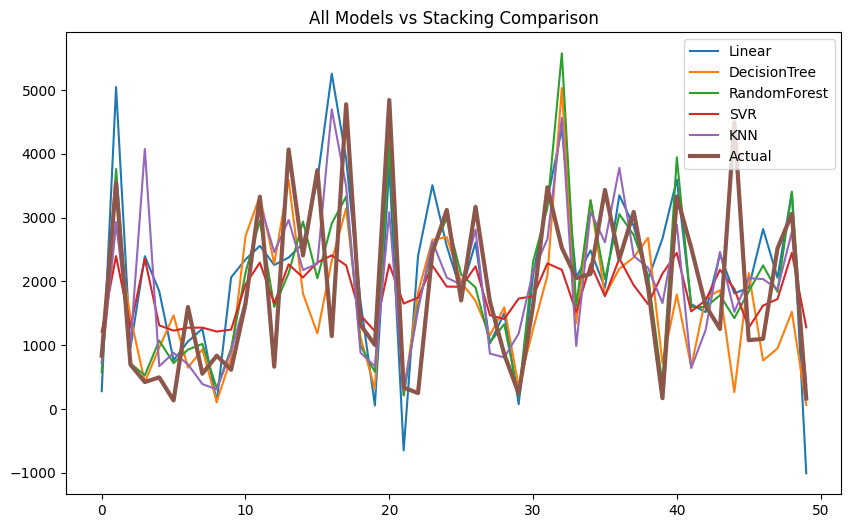

In [24]:
plt.figure(figsize=(10,6))

for name, pred in results.items():
    plt.plot(pred[:50], label=name)

plt.plot(y_test.values[:50], label="Actual", linewidth=3)

plt.legend()
plt.title("All Models vs Stacking Comparison")
plt.show()

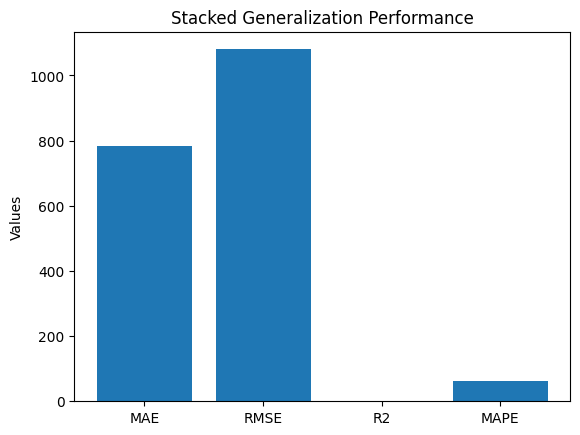

In [44]:
import matplotlib.pyplot as plt

metrics = ["MAE", "RMSE", "R2", "MAPE"]
values = [mae, rmse, r2, mape_val]

plt.bar(metrics, values)
plt.title("Stacked Generalization Performance")
plt.ylabel("Values")
plt.show()

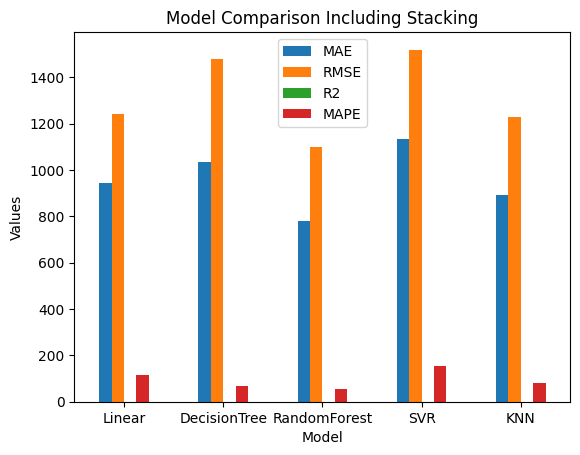

In [45]:
metrics_df.set_index("Model").plot(kind='bar')
plt.title("Model Comparison Including Stacking")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()

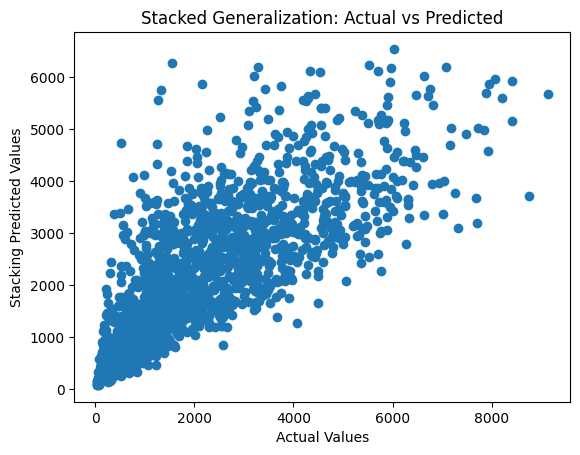

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, stack_pred)
plt.xlabel("Actual Values")
plt.ylabel("Stacking Predicted Values")
plt.title("Stacked Generalization: Actual vs Predicted")
plt.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10)
gb = GradientBoostingRegressor()

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [27]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [28]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
rf_mape = mape(y_test, rf_pred)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)
gb_mape = mape(y_test, gb_pred)

In [29]:
ensemble_df = pd.DataFrame({
    "Model": ["RandomForest", "GradientBoosting"],
    "MAE": [rf_mae, gb_mae],
    "RMSE": [rf_rmse, gb_rmse],
    "R2": [rf_r2, gb_r2],
    "MAPE": [rf_mape, gb_mape]
})

print(ensemble_df)

              Model         MAE         RMSE        R2       MAPE
0      RandomForest  745.407480  1056.409433  0.608694  52.523128
1  GradientBoosting  759.829507  1061.060661  0.605240  62.170762


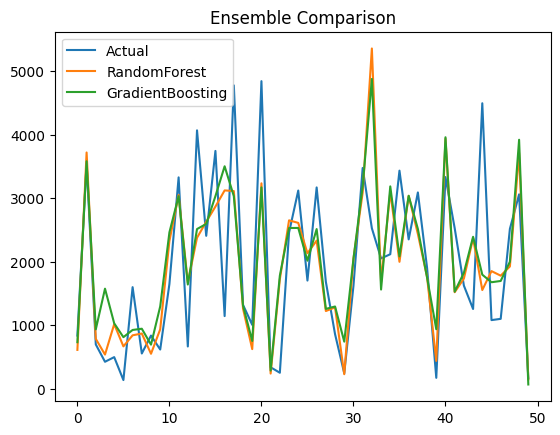

In [30]:
plt.plot(y_test.values[:50], label="Actual")
plt.plot(rf_pred[:50], label="RandomForest")
plt.plot(gb_pred[:50], label="GradientBoosting")
plt.legend()
plt.title("Ensemble Comparison")
plt.show()

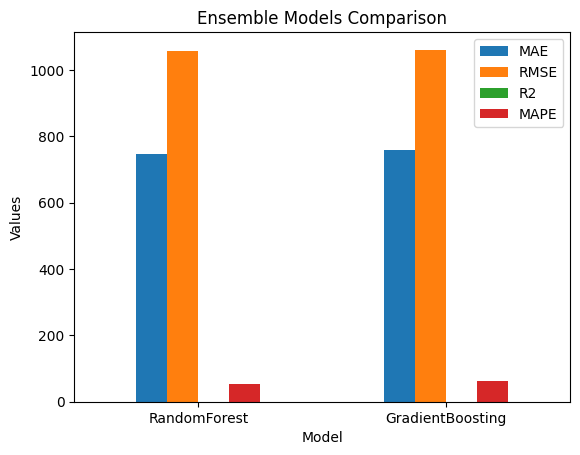

In [31]:
ensemble_df.set_index("Model").plot(kind='bar')
plt.title("Ensemble Models Comparison")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()

In [32]:
print(df.head())
print(df.shape)

   Item_Weight  Item_Visibility  Item_MRP  Item_Outlet_Sales  Item_Age  \
0         9.30         0.016047  249.8092          3735.1380        27   
1         5.92         0.019278   48.2692           443.4228        17   
2        17.50         0.016760  141.6180          2097.2700        27   
3        19.20         0.000000  182.0950           732.3800        28   
4         8.93         0.000000   53.8614           994.7052        39   

   Item_Identifier_DRA24  Item_Identifier_DRA59  Item_Identifier_DRB01  \
0                  False                  False                  False   
1                  False                  False                  False   
2                  False                  False                  False   
3                  False                  False                  False   
4                  False                  False                  False   

   Item_Identifier_DRB13  Item_Identifier_DRB24  ...  \
0                  False                  False  ...  

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
ann = Sequential()

ann.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1))

ann.compile(optimizer='adam', loss='mse')

ann.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

ann_pred = ann.predict(X_test).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [35]:
dnn = Sequential()

dnn.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
dnn.add(Dense(64, activation='relu'))
dnn.add(Dense(32, activation='relu'))
dnn.add(Dense(16, activation='relu'))
dnn.add(Dense(1))

dnn.compile(optimizer='adam', loss='mse')

dnn.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

dnn_pred = dnn.predict(X_test).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [37]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Avoid division by zero
    y_true_safe = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

    return mae, rmse, r2, mape


In [38]:
ann_mae, ann_rmse, ann_r2, ann_mape = evaluate(y_test, ann_pred)
dnn_mae, dnn_rmse, dnn_r2, dnn_mape = evaluate(y_test, dnn_pred)


In [39]:
dl_results = pd.DataFrame({
    "Model": ["ANN", "DNN"],
    "MAE": [ann_mae, dnn_mae],
    "RMSE": [ann_rmse, dnn_rmse],
    "R2": [ann_r2, dnn_r2],
    "MAPE": [ann_mape, dnn_mape]
})

print(dl_results)

  Model         MAE         RMSE        R2       MAPE
0   ANN  866.854671  1170.648211  0.519487  96.202648
1   DNN  812.520603  1144.334282  0.540846  52.202042


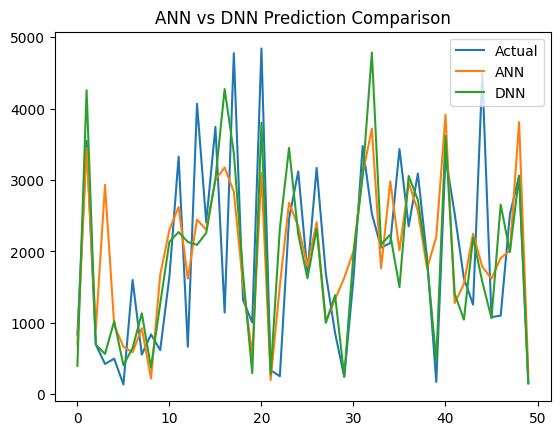

In [43]:
plt.figure()

plt.plot(y_test.values[:50], label="Actual")
plt.plot(ann_pred[:50], label="ANN")
plt.plot(dnn_pred[:50], label="DNN")

plt.legend()
plt.title("ANN vs DNN Prediction Comparison")

plt.show()

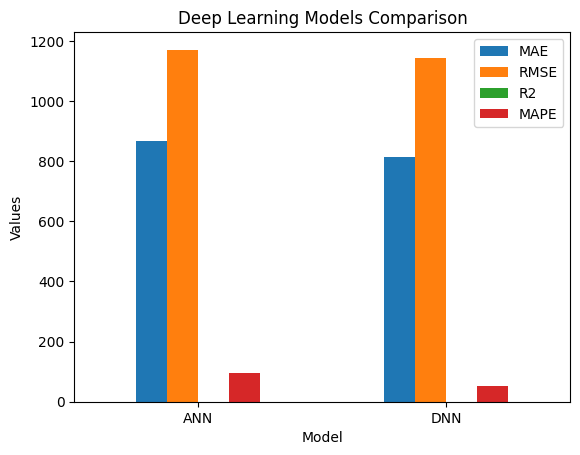

In [40]:
dl_results.set_index("Model").plot(kind='bar')
plt.title("Deep Learning Models Comparison")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()


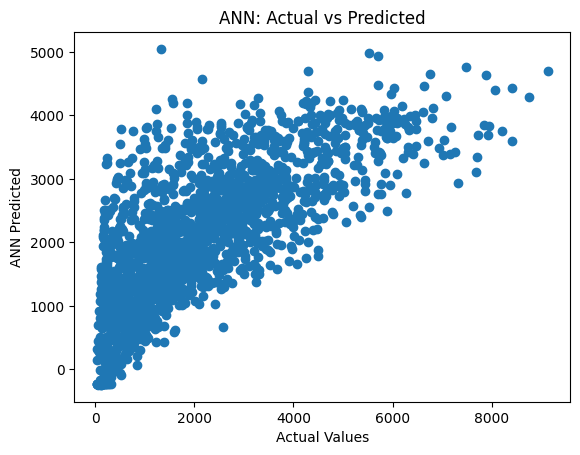

In [41]:
plt.figure()

plt.scatter(y_test, ann_pred)
plt.xlabel("Actual Values")
plt.ylabel("ANN Predicted")
plt.title("ANN: Actual vs Predicted")

plt.show()


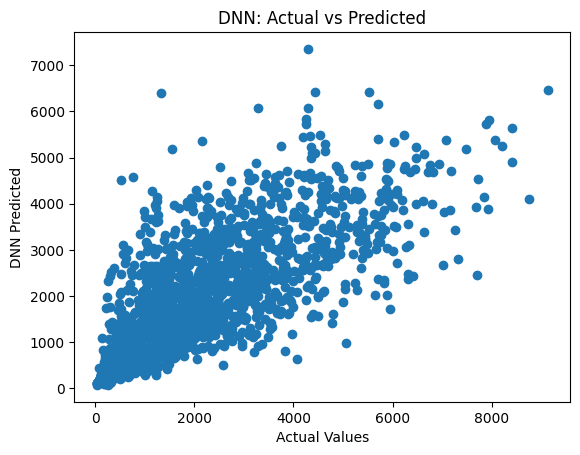

In [42]:
plt.figure()

plt.scatter(y_test, dnn_pred)
plt.xlabel("Actual Values")
plt.ylabel("DNN Predicted")
plt.title("DNN: Actual vs Predicted")

plt.show()



In [46]:
df.to_csv("final_dataset.csv", index=False)

In [47]:
metrics_df.to_csv("model_results.csv", index=False)

In [48]:
dl_results.to_csv("deep_learning_results.csv", index=False)

In [49]:
import pandas as pd

stack_df = pd.DataFrame({
    "Model": ["Stacking"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "MAPE": [mape_val]
})

stack_df.to_csv("stacking_results.csv", index=False)

In [51]:
from google.colab import files
files.download("final_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>